In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('mushrooms.csv')

In [6]:
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [5]:
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [4]:
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])
df_encoded = df.apply(LabelEncoder().fit_transform)

In [5]:
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.ensemble import RandomForestClassifier

In [7]:
df_encoded = df.apply(LabelEncoder().fit_transform)
df_encoded = df_encoded.loc[:, df_encoded.var() > 0]

In [8]:
low_var_features = df_encoded.columns[df_encoded.var() < 0.1]
df_filtered = df_encoded.drop(low_var_features, axis=1)

In [9]:
X = df_filtered.drop('class', axis=1)
y = df_filtered['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

Text(0.5, 1.0, 'Top 10 Important Features')

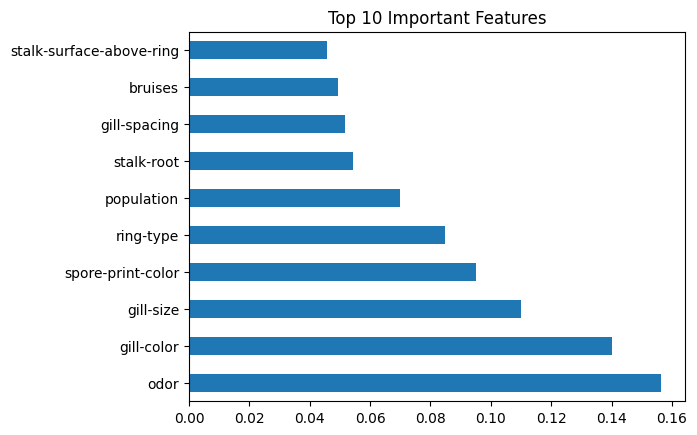

In [10]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")

In [11]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
label_encoders = {}

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

df_encoded.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


In [15]:
X = df_encoded[['gill-color', 'gill-size', 'spore-print-color', 'odor']]

y = df_encoded['class']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

In [16]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [17]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model_rf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9932307692307693
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       842
           1       1.00      0.99      0.99       783

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625



In [41]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

In [42]:
lgbm_wrapper = LGBMClassifier(n_estimators=400)

In [43]:
evals = [(X_test, y_test)]
lgbm_wrapper.fit(X_train, y_train, callbacks=[early_stopping(stopping_rounds=100),log_evaluation(period=1)],eval_metric="logloss", eval_set=evals,)

[1]	valid_0's binary_logloss: 0.601976
Training until validation scores don't improve for 100 rounds
[2]	valid_0's binary_logloss: 0.527909
[3]	valid_0's binary_logloss: 0.466193
[4]	valid_0's binary_logloss: 0.414088
[5]	valid_0's binary_logloss: 0.368599
[6]	valid_0's binary_logloss: 0.329078
[7]	valid_0's binary_logloss: 0.295204
[8]	valid_0's binary_logloss: 0.265424
[9]	valid_0's binary_logloss: 0.238852
[10]	valid_0's binary_logloss: 0.215943
[11]	valid_0's binary_logloss: 0.1958
[12]	valid_0's binary_logloss: 0.177958
[13]	valid_0's binary_logloss: 0.162166
[14]	valid_0's binary_logloss: 0.147635
[15]	valid_0's binary_logloss: 0.135021
[16]	valid_0's binary_logloss: 0.123887
[17]	valid_0's binary_logloss: 0.113844
[18]	valid_0's binary_logloss: 0.104566
[19]	valid_0's binary_logloss: 0.0966678
[20]	valid_0's binary_logloss: 0.0892277
[21]	valid_0's binary_logloss: 0.0826798
[22]	valid_0's binary_logloss: 0.0768281
[23]	valid_0's binary_logloss: 0.0716101
[24]	valid_0's binary_lo

LGBMClassifier(n_estimators=400)

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba_po=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, pred_proba_po)
   
    print("오차 행렬")
    print(confusion)
    print(f"정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")


preds = lgbm_wrapper.predict(X_test)
pred_proba = lgbm_wrapper.predict_proba(X_test)[:,1]

get_clf_eval(y_test, preds, pred_proba)

오차 행렬
[[841   1]
 [  9 774]]
정확도: 0.9938, 정밀도: 0.9987, 재현율: 0.9885, F1: 0.9936, AUC: 0.9997
